Load and inspect the dataset

Read the CSV, check shape, data types, and the label distribution to confirm everything loaded correctly.

In [8]:
import pandas as pd
import numpy as np
import io
import os

# read the raw bytes of the zip file
with open(r'C:\Users\rageg\OneDrive\Desktop\ML Project\DDOS_Dataset.csv', 'rb') as f:
    raw = f.read()

# pandas can read zip files directly using compression parameter
df = pd.read_csv(
    r'C:\Users\rageg\OneDrive\Desktop\ML Project\DDOS_Dataset.csv',
    compression='zip'
)

print(df.shape)
print(df.head())
print(df['label'].value_counts())
print(df.isnull().sum()) # check missing values

(104345, 23)
      dt  switch       src       dst  pktcount  bytecount  dur   dur_nsec  \
0  11425       1  10.0.0.1  10.0.0.8     45304   48294064  100  716000000   
1  11605       1  10.0.0.1  10.0.0.8    126395  134737070  280  734000000   
2  11425       1  10.0.0.2  10.0.0.8     90333   96294978  200  744000000   
3  11425       1  10.0.0.2  10.0.0.8     90333   96294978  200  744000000   
4  11425       1  10.0.0.2  10.0.0.8     90333   96294978  200  744000000   

        tot_dur  flows  ...  pktrate  Pairflow  Protocol  port_no   tx_bytes  \
0  1.010000e+11      3  ...      451         0       UDP        3  143928631   
1  2.810000e+11      2  ...      451         0       UDP        4       3842   
2  2.010000e+11      3  ...      451         0       UDP        1       3795   
3  2.010000e+11      3  ...      451         0       UDP        2       3688   
4  2.010000e+11      3  ...      451         0       UDP        3       3413   

  rx_bytes  tx_kbps  rx_kbps  tot_kbps  lab

Handle missing values

Your dataset has 506 missing values in rx_kbps and tot_kbps. Fill them with the column median — a safe choice for skewed network traffic data.

In [10]:
df['rx_kbps'].fillna(df['rx_kbps'].median())
df['tot_kbps'].fillna(df['tot_kbps'].median())

print(df.isnull().sum().sum())  # should print 0

2024


FEATURE ENGINEERING

In [9]:
# Ratio features — capture relationships between raw counts
df['bytes_per_packet'] = df['bytecount'] / (df['pktcount'] + 1)
df['tx_rx_ratio']      = df['tx_bytes']  / (df['rx_bytes'] + 1)
df['kbps_per_flow']    = df['tot_kbps']  / (df['flows'] + 1)
df['pkt_per_second']   = df['pktcount']  / (df['tot_dur'] + 1)

# Interaction features — combinations that together signal attacks
df['rate_x_flows']      = df['pktrate']   * df['flows']
df['bandwidth_x_pkts']  = df['tot_kbps']  * df['pktcount']
df['packetins_x_flows'] = df['packetins'] * df['flows']

# Confirm new features were added
print(f"New shape: {df.shape}")     # should show 23 + 7 = 30 columns
print("New columns added:")
print([c for c in df.columns if c not in [
    'dt','switch','src','dst','pktcount','bytecount','dur',
    'dur_nsec','tot_dur','flows','packetins','pktperflow',
    'byteperflow','pktrate','Pairflow','Protocol','port_no',
    'tx_bytes','rx_bytes','tx_kbps','rx_kbps','tot_kbps','label'
]])

New shape: (104345, 30)
New columns added:
['bytes_per_packet', 'tx_rx_ratio', 'kbps_per_flow', 'pkt_per_second', 'rate_x_flows', 'bandwidth_x_pkts', 'packetins_x_flows']


Encode categorical features

Three columns are non-numeric: src, dst, and Protocol. Encode them so the model can use them.

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['src']      = le.fit_transform(df['src'].astype(str))
df['dst']      = le.fit_transform(df['dst'].astype(str))
df['Protocol'] = le.fit_transform(df['Protocol'].astype(str))

print(df[['src','dst','Protocol']].head())

   src  dst  Protocol
0    0   16         2
1    0   16         2
2   10   16         2
3   10   16         2
4   10   16         2


Split features and target, then train/test split

Separate X (features) from y (label), then split into 80% training and 20% test set. Stratify to preserve the class ratio in both sets.

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps 61/39 ratio in both splits
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (83476, 29), Test: (20869, 29)


Scale the features

Logistic Regression is sensitive to feature scale. pktcount can be in millions while Protocol is 0–2. StandardScaler brings everything to the same scale. Fit only on training data to avoid data leakage.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)  # fit + transform
X_test_sc  = scaler.transform(X_test)       # transform only!

Train the Logistic Regression model

Initialize and fit the model on the scaled training data. max_iter=1000 gives the solver enough steps to converge on this dataset size.

In [15]:
#from sklearn.linear_model import LogisticRegression
#import time

#lr_model = LogisticRegression(
#    max_iter=1000,
#    random_state=42,
#    solver='lbfgs'    # efficient for large datasets
#)

#start = time.time()
#lr_model.fit(X_train_sc, y_train)
#print(f"Training time: {time.time() - start:.2f}s")

#y_pred = lr_model.predict(X_test_sc)
#y_prob = lr_model.predict_proba(X_test_sc)[:, 1]


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import time

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   # fills NaN with column mean
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'))
])

start = time.time()
pipeline.fit(X_train, y_train)   # use raw X_train, not X_train_sc
print(f"Training time: {time.time() - start:.2f}s")

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

Training time: 0.43s


Evaluate with full metrics

Don't rely on accuracy alone. For DDoS detection, precision and recall matter — a missed attack (false negative) is more costly than a false alarm.

In [16]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print()
print(classification_report(y_test, y_pred,
      target_names=['Normal','DDoS']))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9199769993770665
ROC-AUC  : 0.9678476936996282

              precision    recall  f1-score   support

      Normal       0.94      0.93      0.93     12712
        DDoS       0.90      0.90      0.90      8157

    accuracy                           0.92     20869
   macro avg       0.92      0.92      0.92     20869
weighted avg       0.92      0.92      0.92     20869


Confusion Matrix:
[[11851   861]
 [  809  7348]]


Plot confusion matrix and ROC curve

Visual outputs are essential for your report. These two plots communicate model performance far better than numbers alone.

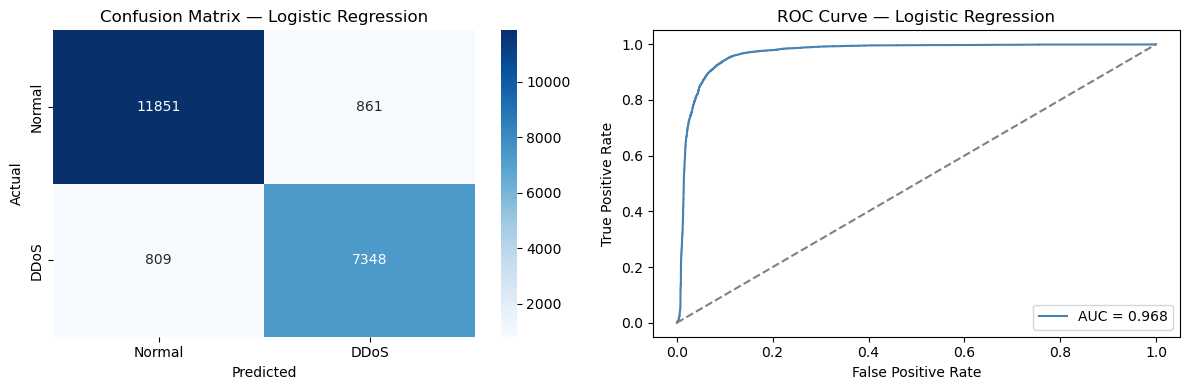

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','DDoS'],
            yticklabels=['Normal','DDoS'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='steelblue')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_title('ROC Curve — Logistic Regression')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('lr_evaluation.png', dpi=150)
plt.show()

Plot feature coefficients

Logistic Regression's coefficients show which features push the prediction toward DDoS (positive) or Normal (negative). This is your model's explainability output.

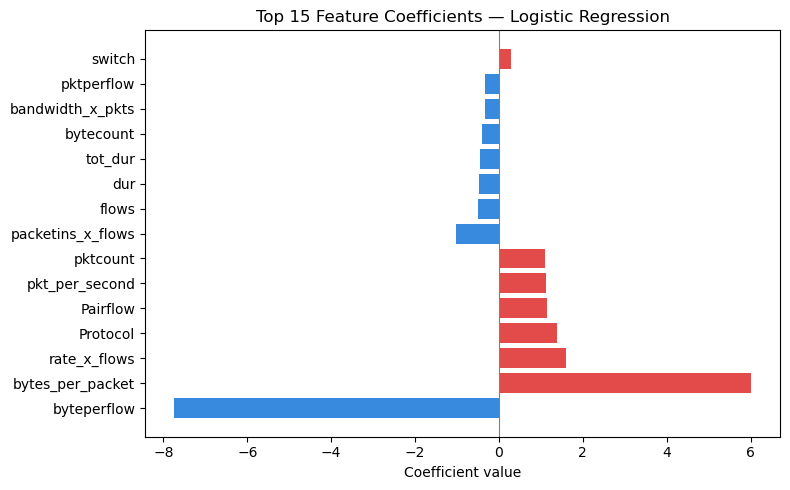

In [19]:
#coef_df = pd.DataFrame({
#    'feature': X.columns,
#    'coefficient': lr_model.coef_[0]
#}).sort_values('coefficient', key=abs, ascending=False).head(15)

#plt.figure(figsize=(8, 5))
#colors = ['#E24B4A' if c > 0 else '#378ADD'
#          for c in coef_df['coefficient']]
#plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
#plt.axvline(0, color='gray', linewidth=0.8)
#plt.title('Top 15 Feature Coefficients — Logistic Regression')
#plt.xlabel('Coefficient value')
#plt.tight_layout()
#plt.savefig('lr_coefficients.png', dpi=150)
#plt.show()


# Extract the trained model from the pipeline
lr_model_step = pipeline.named_steps['model']

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_model_step.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(8, 5))
colors = ['#E24B4A' if c > 0 else '#378ADD'
          for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title('Top 15 Feature Coefficients — Logistic Regression')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150)
plt.show()

Store results for comparison

Save metrics in a dictionary now. You'll add all 5 models to this and generate a final comparison table and chart at the end.

In [20]:
results = {}   # create this once, reuse across all models

results['Logistic Regression'] = {
    'accuracy' : accuracy_score(y_test, y_pred),
    'roc_auc'  : roc_auc_score(y_test, y_prob),
    'precision': classification_report(y_test, y_pred,
                   output_dict=True)['1']['precision'],
    'recall'   : classification_report(y_test, y_pred,
                   output_dict=True)['1']['recall'],
    'f1'       : classification_report(y_test, y_pred,
                   output_dict=True)['1']['f1-score'],
}

print(pd.DataFrame(results).T)

                     accuracy   roc_auc  precision    recall        f1
Logistic Regression  0.919977  0.967848   0.895115  0.900821  0.897959
